## Initializing a quantum device

Each `Device` in QoolQit wraps a [Pulser](https://pulser.readthedocs.io/en/stable/tutorials/virtual_devices.html#) device and defines the hardware characteristics that the program will be compiled to and later executed on.

In [18]:
from qoolqit import MockDevice, AnalogDevice, DigitalAnalogDevice

# An example of a mock device with no hardware constraints
device_ideal = MockDevice()

# An example of a real device
device_real = AnalogDevice()

# An example of a real device with digital-analog capabilities.
device_real_digital = DigitalAnalogDevice()

The updated list of available devices is given below:

In [19]:
from qoolqit import available_default_devices

available_default_devices()

AnalogDevice: A realistic device for analog sequence execution.
 └── max_duration: 332.43763968
 └── max_amplitude: 0.22680411206965717
 └── max_abs_detuning: 2.268041120696572
 └── min_distance: 1.0
 └── max_radial_distance: 7.6

DigitalAnalogDevice: A device with digital and analog capabilites.
 └── max_duration: None
 └── max_amplitude: 0.011870467845064849
 └── max_abs_detuning: 0.09496374276051879
 └── min_distance: 1.0
 └── max_radial_distance: 12.5

MockDevice: A virtual device for unconstrained prototyping.
 └── max_duration: None
 └── max_amplitude: None
 └── max_abs_detuning: None
 └── min_distance: 0.0
 └── max_radial_distance: None



Besides available default devices, relevant for QPU emulation, new QPU devices can be:
- imported remotely
- created from custom Pulser devices

#### Fetching a QoolQit device from a connection
Depending on your provider you might have different QPUs available to launch your quantum program to.
The list of available ones can be fetched through the specific connection handler object, with the generic `connection.fetch_available_devices()` method.

For the Pasqal Cloud service, for example, creating a QoolQit device from a connection object, simply reads as:

In [20]:
from pulser_pasqal import PasqalCloud
from qoolqit import Device

connection = PasqalCloud()
print(connection.fetch_available_devices())

# fetch QoolQit device
fresnel_device = Device.from_connection(connection=connection, name="FRESNEL")
print(fresnel_device)

{'FRESNEL': FRESNEL}
FRESNEL: 
 └── max_duration: 332.43763968
 └── max_amplitude: 0.20412370086269147
 └── max_abs_detuning: 1.134020560348286
 └── min_distance: 1.0
 └── max_radial_distance: 9.2



On a QRMI-enabled cluster, you can pass `PulserQRMIConnection()` as the connection and submit the same script with `sbatch --qpu=<backend> ...` (for example `FRESNEL` or `EMU_FREE`).

For a Qaptiva managed cluster, you can similarly pass `PulserQLMConnection()`.

### Create a QoolQit device from a Pulser device
A custom QoolQit device can also be built straight from any Pulser device, with any desired specification.
Please, refer to [Pulser documentation](https://docs.pasqal.com/pulser/tutorials/virtual_devices/) to learn how to make a custom device.

In [21]:
from dataclasses import replace
from pulser import AnalogDevice
from qoolqit import Device

# Converting the pulser Device object into a VirtualDevice object
VirtualAnalog = AnalogDevice.to_virtual()
# Replacing desired values
ModdedAnalogDevice = replace(VirtualAnalog, max_radial_distance=100, max_sequence_duration=7000)

# Wrap a Pulser device object into a QoolQit Device
mod_analog_device = Device(pulser_device=ModdedAnalogDevice)
print(mod_analog_device)

AnalogDevice: 
 └── max_duration: 387.84391296
 └── max_amplitude: 0.22680411206965717
 └── max_abs_detuning: 2.268041120696572
 └── min_distance: 1.0
 └── max_radial_distance: 20.0



## Compilation

Once a `QuantumProgram` is defined and a `Device` is selected one can proceed with the compilation by means of the method `compile_to`. This method will execute what has been discussed in the [introduction](./rationale.md) mapping adimensional parameters to physical quantities according to specific default rules.

In [22]:
from qoolqit import PiecewiseLinear
from qoolqit import Register, Drive, QuantumProgram
from qoolqit import AnalogDevice

# Defining the Drive
wf0 = PiecewiseLinear([1.0, 2.0, 1.0], [0.0, 0.5, 0.5, 0.0])
wf1 = PiecewiseLinear([1.0, 2.0, 1.0], [-1.0, -1.0, 1.0, 1.0])
drive = Drive(amplitude = wf0, detuning = wf1)

# Defining the Register
coords = [(0.0, 0.0), (0.0, 1.0), (1.0, 0.0), (1.0, 1.0)]
register = Register.from_coordinates(coords)

# Creating the Program
program = QuantumProgram(register, drive)
device = AnalogDevice()

# Compilation to AnalogDevice
program.compile_to(device)
print(program)

Quantum Program:
| Register(n_qubits = 4)
| Drive(duration = 4.000)
| Compiled: True
| Device: AnalogDevice


Now that the program has been compiled, we can inspect the compiled sequence, which is an instance of a Pulser `Sequence`.

In [23]:
pulser_sequence = program.compiled_sequence

Finally, we can draw both the original program and the compiled sequence.

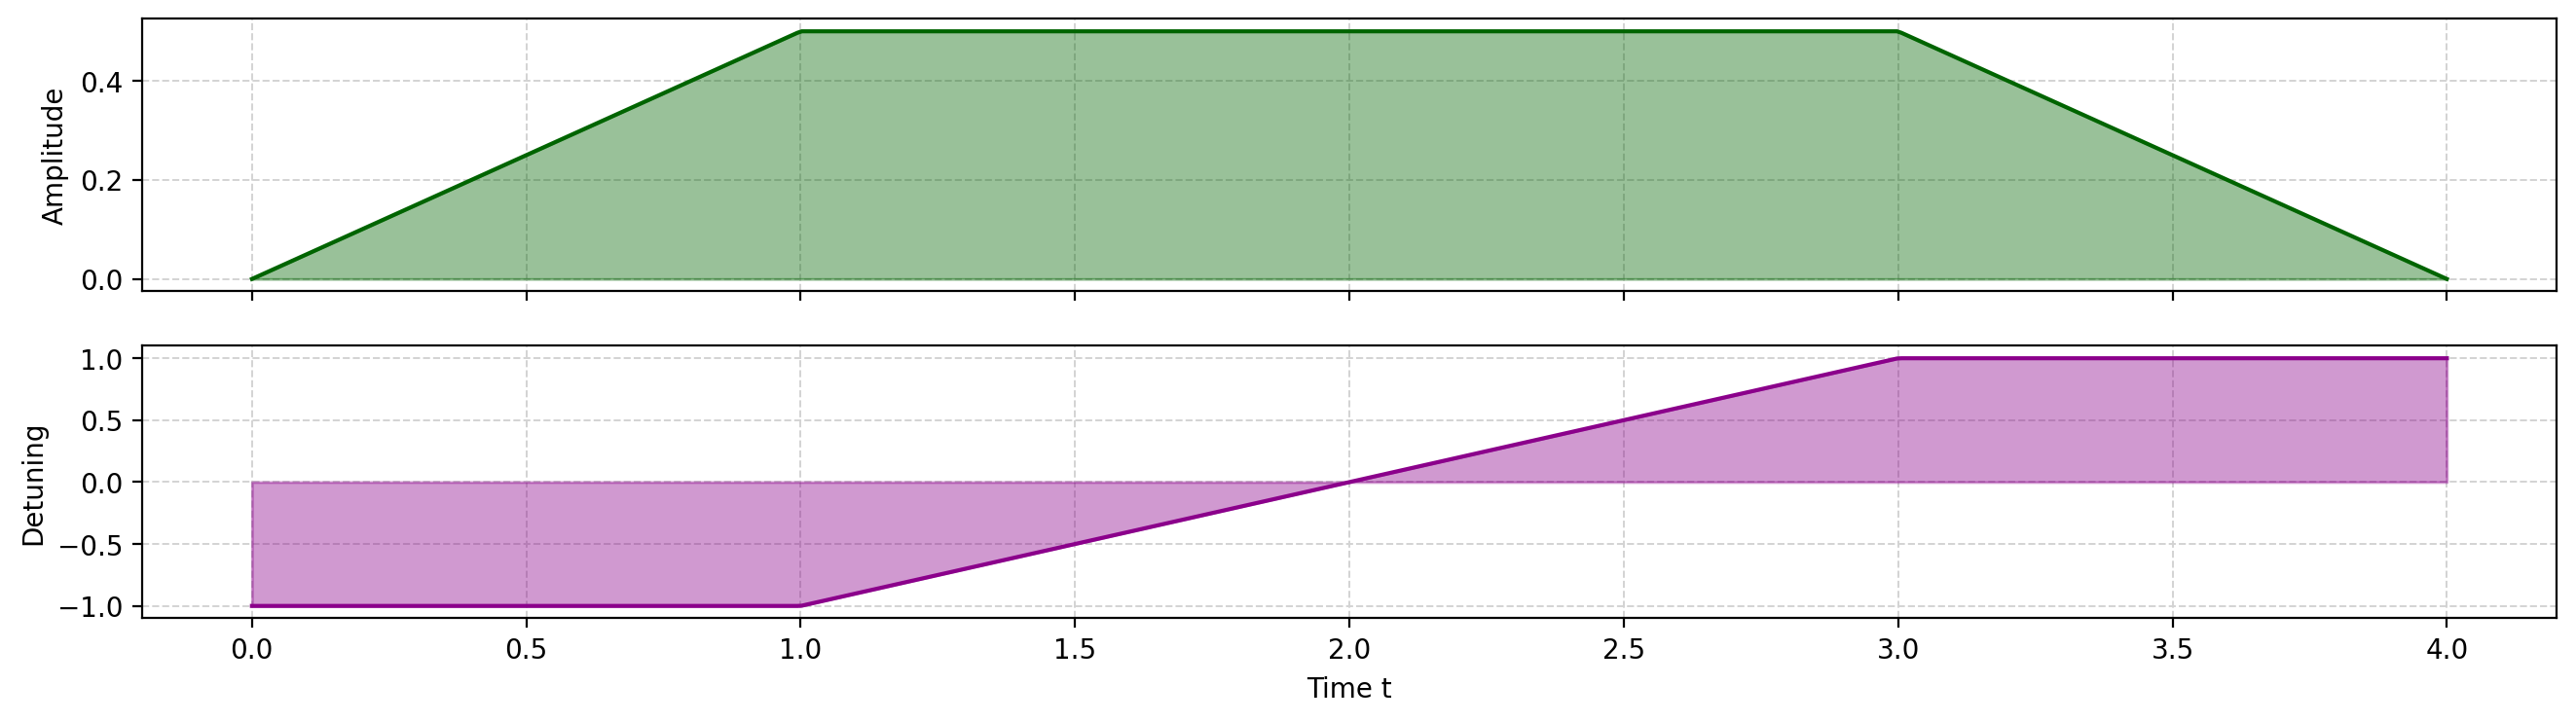

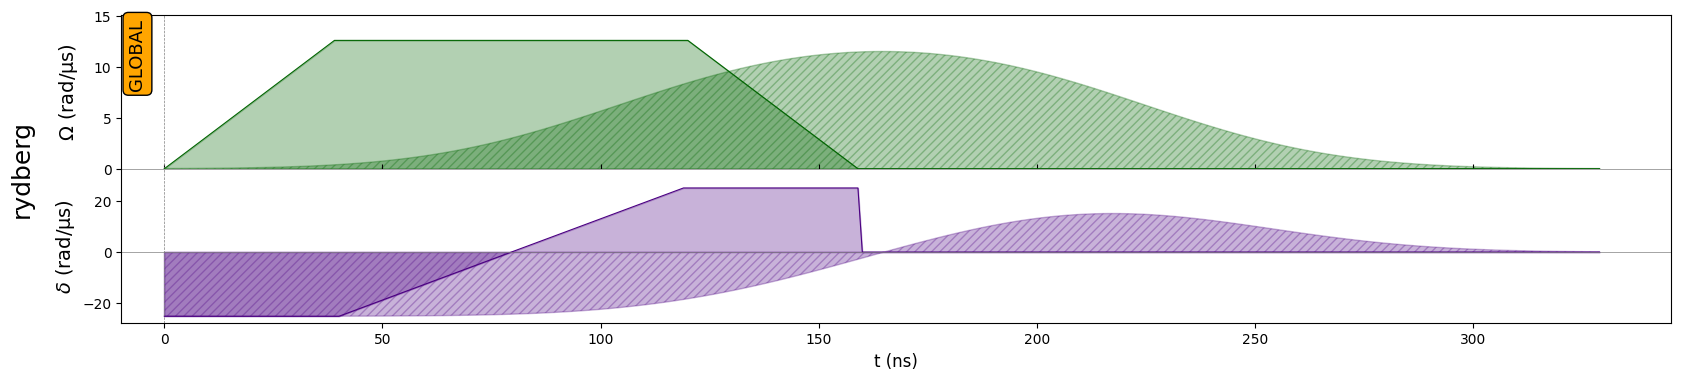

In [24]:
program.draw()
program.draw(compiled = True)

## Special compilation: maximum allowed duration
Whenever possible, the compilation step in QoolQit will simply take care of mapping the input quantum program into real hardware instructions.
In other words, ratios between energies (interactions and drive) and time will be preserved (see [compilation rationale](./rationale.md)).
However, in some applications, one may be interested in separating time from the compilation step.
For example, in adiabatic protocols, one simply seeks to rescale the duration of a quantum program to the maximum value allowed by the specific hardware.

To do so, set the corresponding flag at compilation:

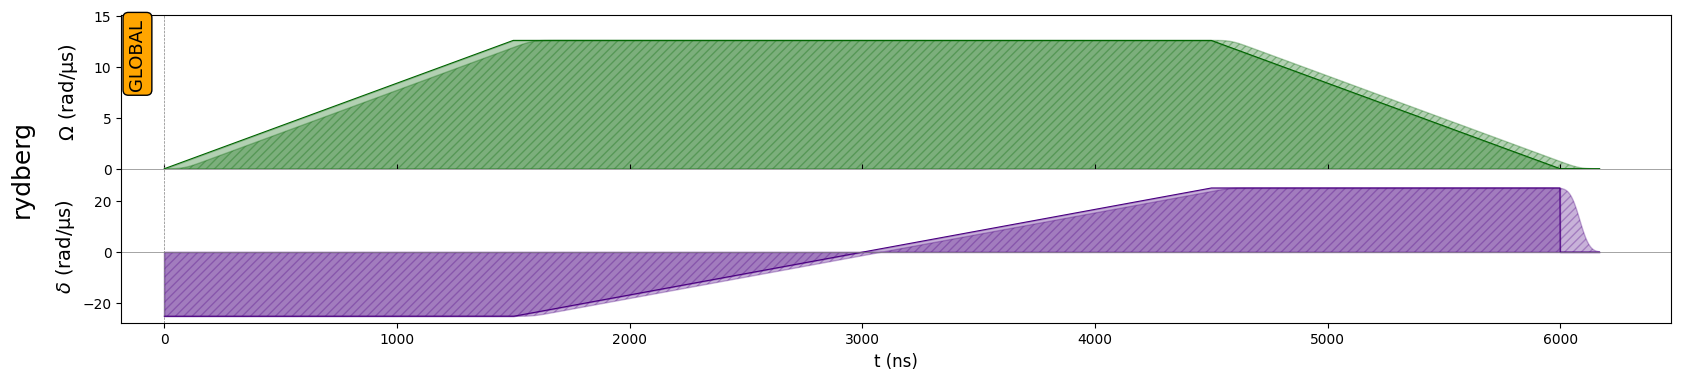

In [25]:
# Compilation to AnalogDevice max duration
program.compile_to(device, device_max_duration_ratio=1.0)
program.draw(compiled = True)

As anticipated, this flag will decouple time from the compilation, letting the user set a time relative to the maximum allowed by the selected device.
Moreover, as a drive's amplitude/detuning can be composed by many waveforms, this feature will rescale them preserving their relative durations.

Finally, it is important to highlight that:

!!! warning
    Programs compiled with the flag `device_max_duration_ratio` are not portable across different devices.
    The same program compiled on two different devices will be different.